In [2]:
import numpy as np ###
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler ### 对变量进行标准化
from matplotlib.ticker import MaxNLocator 

In [3]:
lines = np.loadtxt('USA_Housing.csv', delimiter=',', dtype='str')
header = lines[0]
lines = lines[1:]
lines = lines.astype(float)
print(f"特征为:{','.join(header)}")
print(f"数据标签为:{lines[:,-1]}")
print(f"数据量为：{lines.shape[0]}")
### 划分数据
ratio = 0.8
split = int(lines.shape[0] * ratio)
np.random.seed(0)
index = np.random.permutation(range(lines.shape[0]))
lines = lines[index]
train, test = lines[:split], lines[split:]
### 归一化
scalar = StandardScaler()
scalar.fit(train)
train = scalar.transform(train)
test = scalar.transform(test)
###
x_train, y_train = train[:,:-1], train[:,-1].flatten()
x_test, y_test = test[:,:-1], test[:,-1].flatten()


特征为:Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
数据标签为:[1059033.55787012 1505890.91484695 1058987.98787608 ... 1030729.58315229
 1198656.87240769 1298950.48026696]
数据量为：5000


In [17]:
X = np.concatenate([x_train,np.ones(shape=(len(x_train),1))],axis=1)
theta = np.linalg.inv(X.T @ X) @ X.T @ y_train
theta = theta.reshape(len(theta),-1)
print(theta)
print(theta.shape)

[[ 6.50881254e-01]
 [ 4.67222833e-01]
 [ 3.38466198e-01]
 [ 6.17275856e-03]
 [ 4.26857089e-01]
 [-1.46133106e-14]]
(6, 1)


In [19]:
X_test = np.concatenate([x_test,np.ones((len(x_test),1))], axis = 1)
y_pred = X_test @ theta
print(y_pred.flatten())

[ 1.41235865e+00 -2.57937692e-01  1.83127966e+00  4.68714724e-01
  8.61153967e-01  7.54668751e-03 -1.73107134e+00 -1.36727311e+00
  6.32559339e-01  1.95291639e-01  1.02037227e+00 -7.39184986e-01
  8.85795599e-01  6.36246636e-01 -2.33579453e-01  2.58242312e-01
 -6.81271962e-01  1.88137695e-01  1.06852239e+00  6.13917061e-01
 -3.77440985e-01  3.98344892e-02 -1.36208805e+00  1.86255273e-01
  2.03494737e+00 -8.43813383e-01  1.43726713e+00  3.98718246e-01
  1.60452726e+00  1.28171867e-01  2.07795986e+00 -4.44905755e-01
  1.63270208e+00 -1.17973475e+00 -3.63844785e-01 -1.43420176e-01
 -1.18299447e+00 -1.28278548e+00  2.57054072e-03  5.08353777e-01
 -6.03063420e-02 -9.17255337e-01  7.99438103e-01  1.76679584e-01
 -1.20249532e+00  1.26125253e-01 -1.39277966e+00 -7.83149018e-01
 -9.90319300e-01 -7.44572326e-01  8.86571042e-01 -9.15579273e-01
  2.37184044e+00  1.37391977e+00 -6.02871767e-01  8.90806778e-01
  9.18878965e-01 -3.79989439e-01 -6.91439084e-01  2.60141823e-01
  5.14237422e-01  1.00836

In [32]:
rmse = np.sqrt((np.square(y_test - y_pred.flatten())).mean())
print(rmse)

0.28791834247503534


## 使用sklearn套件完成回归

In [33]:
from sklearn.linear_model import LinearRegression

In [38]:
linreg = LinearRegression()
linreg.fit(x_train,y_train)
print(f"系数为{linreg.coef_}和{linreg.intercept_}")

rmse = np.sqrt(np.square(y_test - linreg.predict(x_test)).mean())
print(rmse)

系数为[0.65088125 0.46722283 0.3384662  0.00617276 0.42685709]和-1.4635041882766183e-14
0.28791834247503534


In [ ]:
### 使用SGD进行梯度下降
def batch_generator(x,y,batch_size, shuffle = True):
    batch_count = 0
    if shuffle:
        idx = np.random.permutation(len(x))
        x = x[idx]
        y = y[idx]
    while True:
        start = batch_count * batch_size
        end = min(start + batch_size, len(x))
        batch_count += 1
        if start >= end:
            break
        
        yield x[start:end], y[start:end]

# x_sim = np.array([[1,2,3],
#                   [3,4,5],
#                   [5,6,7]])
# y_sim = np.array([1,2,3])

# batch_generator(x_sim,y_sim,batch_size=1)
# for i in batch_generator(x_sim,y_sim,batch_size=1):
#     print(i)

(array([[5, 6, 7]]), array([3]))
(array([[3, 4, 5]]), array([2]))
(array([[1, 2, 3]]), array([1]))


回归系数是[0.65085798 0.46748984 0.33775399 0.00539509 0.42670711 0.00391454]


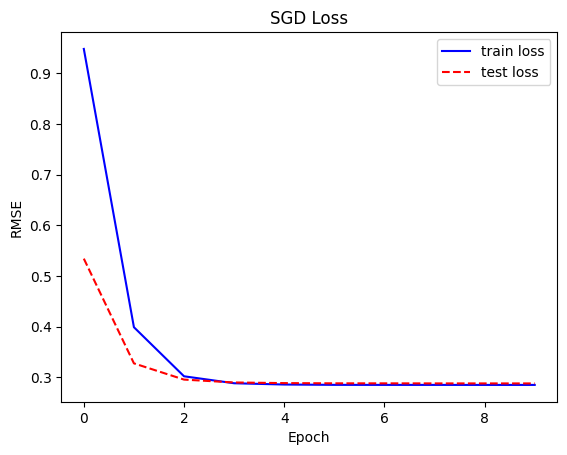

In [69]:
def SGD(x_train,y_train,x_test,y_test,n_epochs,batch_size,learning_rate):
    ### 合成数据
    X_train = np.concatenate([x_train,np.ones((len(x_train),1))],axis=1)
    X_test = np.concatenate([x_test,np.ones((len(x_test),1))],axis=1)
    ### 初始theta
    theta = np.random.normal(size=X_train.shape[1])
    ### 储存loss
    loss_trains = []
    loss_tests = []
    ### 循环epoch 和 batch
    for i in range(n_epochs):
        loss_train = 0
        for x,y in batch_generator(X_train,y_train,batch_size):
            grad = x.T @ (x @ theta - y)/len(x)
            theta = theta - learning_rate * grad
            loss_train = loss_train + sum(np.square(x @ theta - y))
        loss_trains.append(np.sqrt(loss_train/len(X_train)))
        loss_tests.append(np.sqrt((np.square(X_test @ theta - y_test)).mean())) 
    print(f"回归系数是{theta}")

    return theta, loss_trains, loss_tests
# test
n_epochs = 10
batch_size = 32
learning_rate = 0.01
theta, loss_trains, loss_tests = SGD(x_train,y_train,x_test,y_test,n_epochs,batch_size,learning_rate)
# plt.plot(loss_trains, label='train loss')
# plt.plot(loss_tests, label='test loss')
plt.plot(np.arange(n_epochs),loss_trains,label = 'train loss', ls = '-',color = 'blue')
plt.plot(np.arange(n_epochs),loss_tests,label = 'test loss', ls = '--',color = 'red')

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('SGD Loss')
plt.legend()
plt.show()


回归系数是[ 0.65764858  0.47122652  0.33007756 -0.00688708  0.44121032  0.00741831]
回归系数是[ 0.50298593  0.60972195  0.27115306 -0.27470317  0.16820619  0.00182452]


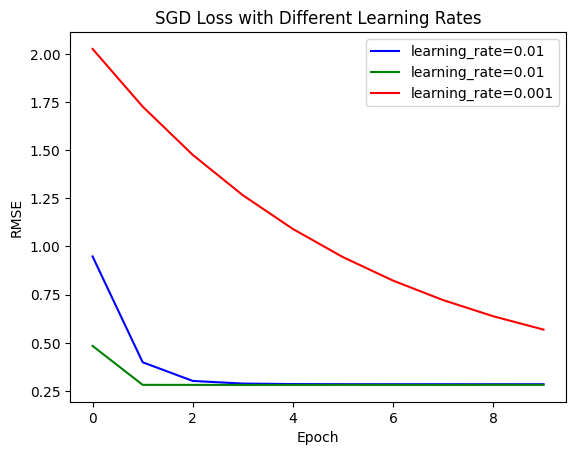

In [71]:
_,loss1,_ = SGD(x_train,y_train,x_test,y_test,n_epochs=10,batch_size=32,learning_rate=0.1)
_,loss2,_ = SGD(x_train,y_train,x_test,y_test,n_epochs=10,batch_size=32,learning_rate=0.001)
plt.plot(np.arange(n_epochs),loss_trains, label='learning_rate=0.01', color = 'blue')
plt.plot(np.arange(n_epochs),loss1, label='learning_rate=0.01', color = 'green')
plt.plot(np.arange(n_epochs),loss2, label='learning_rate=0.001', color = 'red')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('SGD Loss with Different Learning Rates')
plt.legend()
plt.show()


回归系数是[ 5.36001342e+38  1.30775725e+37  8.28272079e+38  9.80256791e+38
 -2.38246294e+38 -5.25367080e+38]


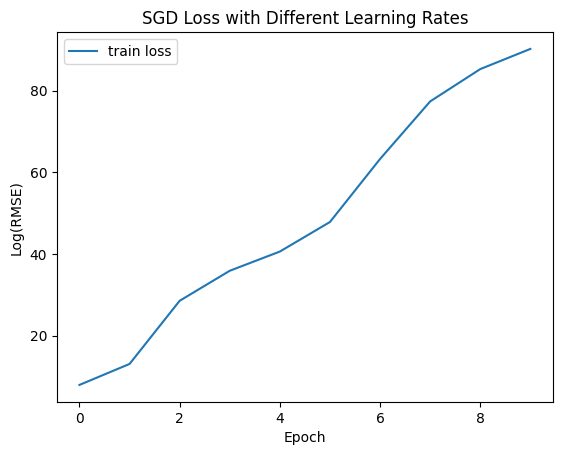

In [59]:
_,loss3,_ = SGD(x_train,y_train,x_test,y_test,n_epochs=10,batch_size=32,learning_rate = 1.5)
plt.plot(np.arange(n_epochs), np.log(loss3), label='train loss')
plt.xlabel('Epoch')
plt.ylabel('Log(RMSE)')
plt.title('SGD Loss with Different Learning Rates')
plt.legend()
plt.show()

In [64]:
def test(*args, **kwargs):
    print(type(args))
    for i in args:
        print(i)
    for k in kwargs:
        print(f"{k}")

test(1,2,3, name="Alice", age=30)

<class 'tuple'>
1
2
3
name
age
